<a href="https://colab.research.google.com/github/AiHuzaifa/Ml-Algos-from-scratch/blob/main/K_NN_from_scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

KNN Accuracy (K=5): 100.0%


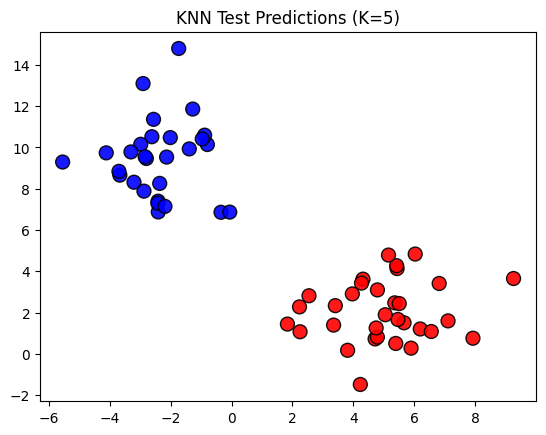

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

X_raw, y_raw = make_blobs(n_samples=300, centers=2, cluster_std=1.5, random_state=42)

# Perform the Train/Test split (80/20)
m = X_raw.shape[0]
shuffled_indices = np.random.permutation(m)
train_size = int(m * 0.8)

X_train = X_raw[shuffled_indices[:train_size]]
y_train = y_raw[shuffled_indices[:train_size]]

X_test = X_raw[shuffled_indices[train_size:]]
y_test = y_raw[shuffled_indices[train_size:]]

# ==========================================
# 2. THE KNN ALGORITHM
# ==========================================
def predict_knn(X_train, y_train, X_test, k=3):
    predictions = []

    # Loop through every single point in the unseen test set
    for p in X_test:
        # Step 1: Calculate Euclidean distance from 'p' to ALL training points
        # np.sum(..., axis=1) ensures we sum across the features for each row
        distances = np.sqrt(np.sum((X_train - p)**2, axis=1))

        # Step 2: Sort distances and get the index numbers of the top K smallest
        k_indices = np.argsort(distances)[:k]

        # Step 3: Extract the actual labels (0 or 1) of those K neighbors
        k_nearest_labels = y_train[k_indices]

        # Step 4: Majority Vote. np.bincount counts occurrences of each class, argmax finds the highest count
        most_common_label = np.bincount(k_nearest_labels).argmax()

        predictions.append(most_common_label)

    return np.array(predictions)

# ==========================================
# 3. EVALUATION
# ==========================================
def calculate_accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred) * 100

# Run the prediction using K=5
k_value = 5
final_predictions = predict_knn(X_train, y_train, X_test, k=k_value)

# Calculate and print accuracy
accuracy = calculate_accuracy(y_test, final_predictions)
print(f"KNN Accuracy (K={k_value}): {accuracy}%")

# Optional: Visualize the test predictions
plt.scatter(X_test[:, 0], X_test[:, 1], c=final_predictions, cmap='bwr', edgecolor='k', alpha=0.9, s=100)
plt.title(f"KNN Test Predictions (K={k_value})")
plt.show()